<a href="https://colab.research.google.com/github/mayurpophale/data_science/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout
from tensorflow.keras.utils import to_categorical

In [24]:
df = pd.read_csv('/content/mnist_train[1].csv')
df_test = pd.read_csv('/content/mnist_test[1].csv')

In [25]:
X_train = df.drop('label',axis=1).values
y_train = df['label'].values
X_test = df_test.drop('label',axis=1).values
y_test = df_test['label'].values

In [26]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [28]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [30]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

## **Percetron**

In [31]:
percetron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')]
)

In [32]:
percetron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [33]:
hist_percetron = percetron.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,
                               validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8199 - loss: 0.7763 - val_accuracy: 0.8827 - val_loss: 0.4775
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8820 - loss: 0.4537 - val_accuracy: 0.8959 - val_loss: 0.3984
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8919 - loss: 0.4019 - val_accuracy: 0.9025 - val_loss: 0.3656
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8975 - loss: 0.3759 - val_accuracy: 0.9060 - val_loss: 0.3481
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9011 - loss: 0.3593 - val_accuracy: 0.9096 - val_loss: 0.3351


In [34]:
acc_per = percetron.evaluate(X_test_img,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9096 - loss: 0.3351


## **ANN**

In [35]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')]
)

In [36]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [37]:
hist_ann = ann.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,
                   validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9285 - loss: 0.2463 - val_accuracy: 0.9638 - val_loss: 0.1171
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9689 - loss: 0.1037 - val_accuracy: 0.9697 - val_loss: 0.0967
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9782 - loss: 0.0719 - val_accuracy: 0.9719 - val_loss: 0.0852
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9824 - loss: 0.0558 - val_accuracy: 0.9718 - val_loss: 0.0915
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9865 - loss: 0.0432 - val_accuracy: 0.9782 - val_loss: 0.0727


In [38]:
acc_ann = ann.evaluate(X_test_img,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9782 - loss: 0.0727


## **CNN**

In [39]:
X_test_img_cnn = X_test_img.reshape(-1,28,28,1)
X_train_img_cnn = X_train_img.reshape(-1,28,28,1)

In [40]:
cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')]
)

In [41]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [42]:
hist_cnn = cnn.fit(X_train_img_cnn,y_train_cat,epochs=5,batch_size=32,
                   validation_data=(X_test_img_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.9370 - loss: 0.2061 - val_accuracy: 0.9872 - val_loss: 0.0416
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.9794 - loss: 0.0704 - val_accuracy: 0.9892 - val_loss: 0.0324
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.9832 - loss: 0.0547 - val_accuracy: 0.9914 - val_loss: 0.0261
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 37ms/step - accuracy: 0.9875 - loss: 0.0423 - val_accuracy: 0.9901 - val_loss: 0.0287
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - accuracy: 0.9882 - loss: 0.0378 - val_accuracy: 0.9907 - val_loss: 0.0268


In [43]:
acc_cnn = cnn.evaluate(X_test_img_cnn,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9907 - loss: 0.0268


## **Comparision**

In [45]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

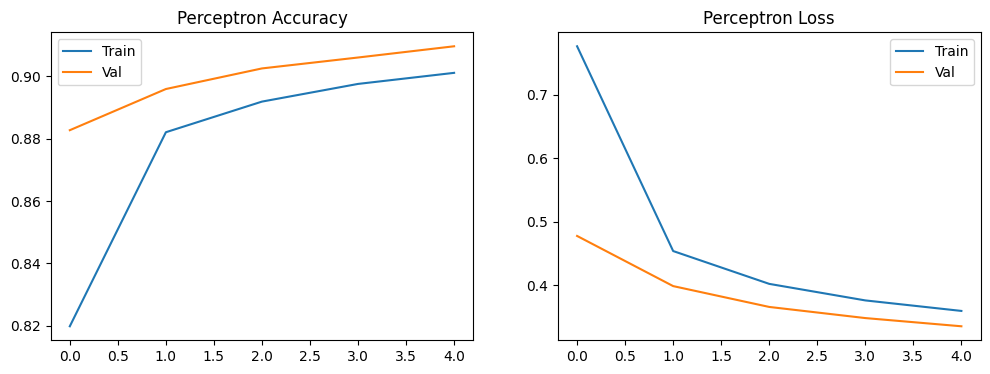

In [47]:
plot_training(hist_percetron, "Perceptron")


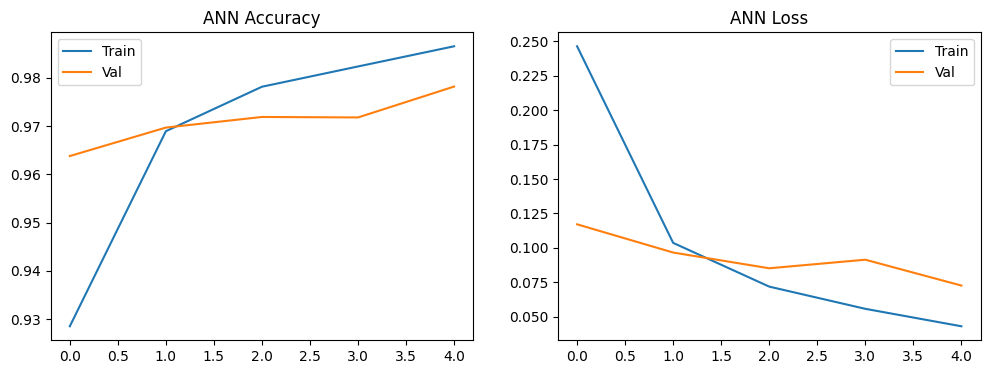

In [48]:
plot_training(hist_ann, "ANN")

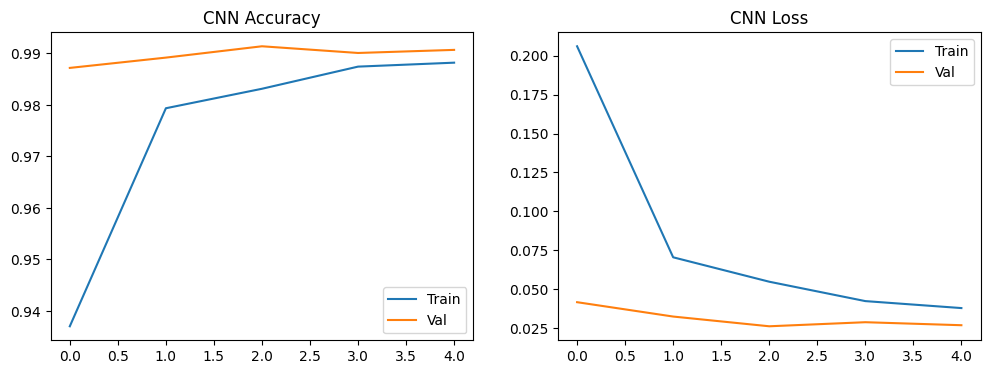

In [49]:
plot_training(hist_cnn, "CNN")

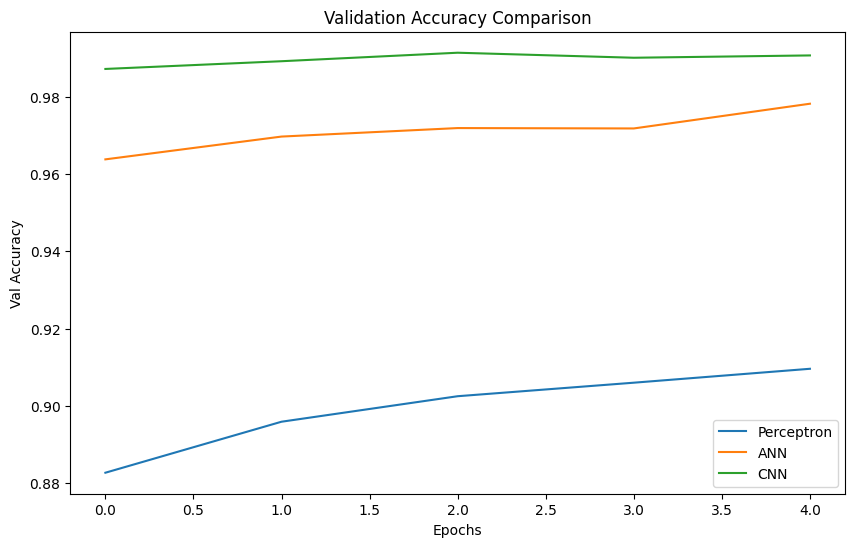

In [51]:
plt.figure(figsize=(10,6))
plt.plot(hist_percetron.history['val_accuracy'], label="Perceptron")
plt.plot(hist_ann.history['val_accuracy'], label="ANN")
plt.plot(hist_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [52]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


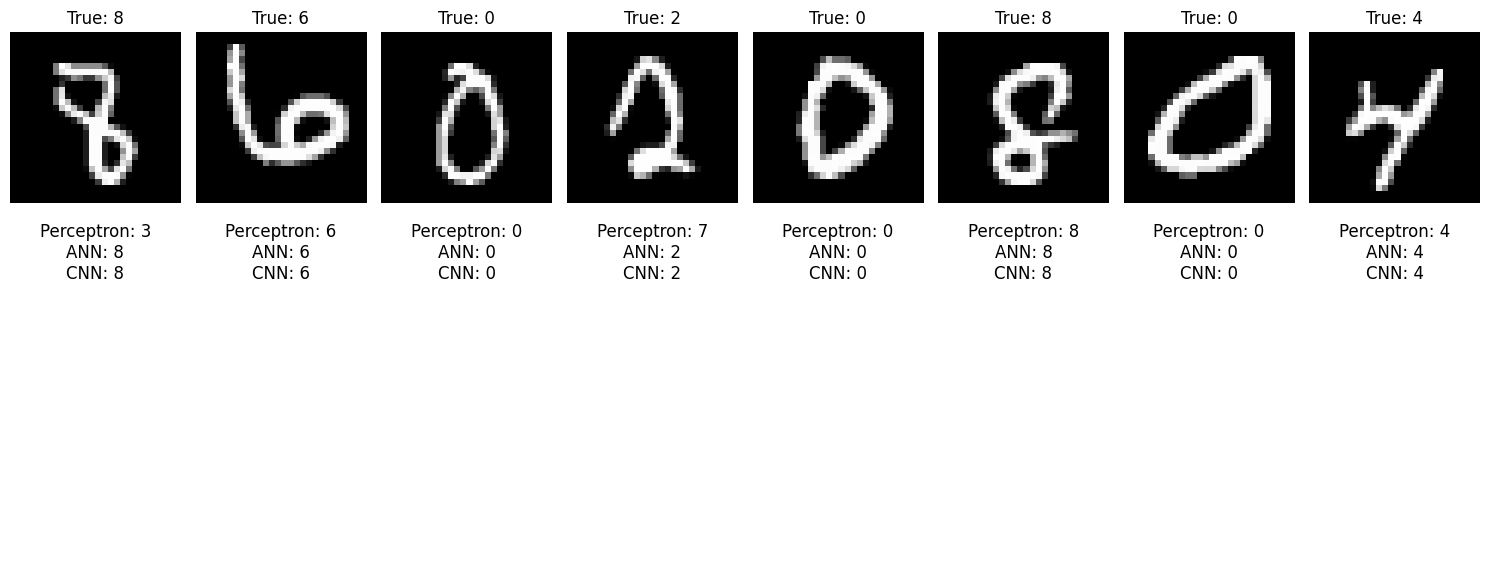

In [54]:
show_side_by_side([percetron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test, X_test_img_cnn, y_test, n=8)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


Text(95.72222222222221, 0.5, 'True')

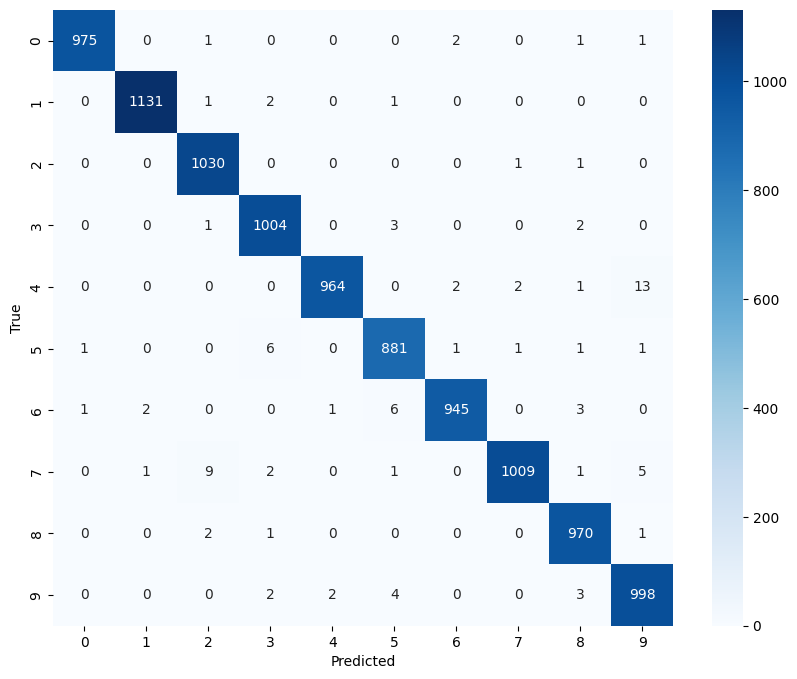

In [55]:
#confusion matrix
y_pred = cnn.predict(X_test_img_cnn)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')

Perceptron Accuracy: 0.9096
ANN Accuracy: 0.9782
CNN Accuracy: 0.9907


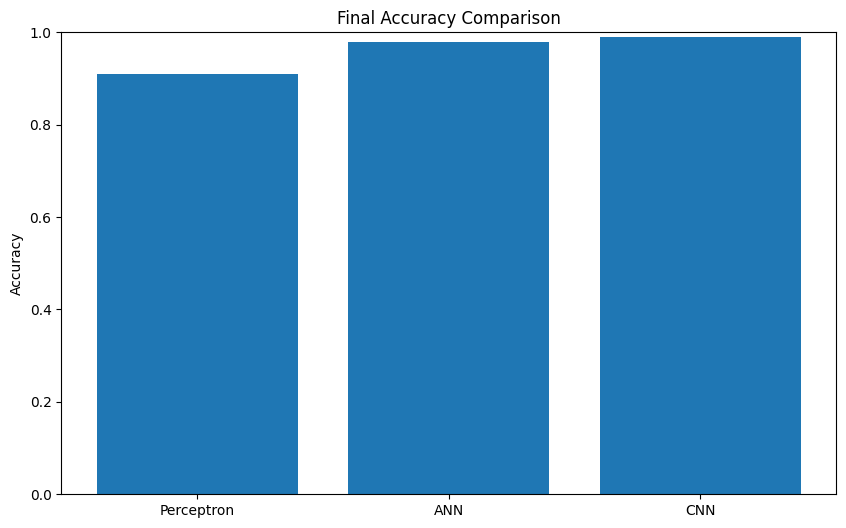

In [58]:
#Final Acc Comparision
print(f"Perceptron Accuracy: {acc_per:.4f}")
print(f"ANN Accuracy: {acc_ann:.4f}")
print(f"CNN Accuracy: {acc_cnn:.4f}")
plt.figure(figsize=(10,6))
plt.bar(['Perceptron', 'ANN', 'CNN'], [acc_per, acc_ann, acc_cnn])
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.title('Final Accuracy Comparison')
plt.show()